<a href="https://colab.research.google.com/github/laura-ctrl-a/Portfolio-Optimization/blob/main/Ptf_Implementation_and_graphs_GITHUB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Developed a Mixed-Integer Linear Programming (MILP) model in Python to optimize a financial portfolio of 8 assets (AAPL, MSFT, GOOG, SAP, RGTI, TSLA, GLD, BTC-USD), using real historical price data from Yahoo Finance (2016–2026).
The model selects a minimum of 5 assets and allocates capital within per-asset bounds, maximizing a risk-return trade-off controlled by a tunable alpha parameter. The risk measures considered is MAD (Mean Absolute Deviation), linearized directly in the MILP formulation

Key features:
— Budget constraint ($10,000 capital)
— Minimum diversification (≥ 5 assets)
— Per-asset allocation bounds (floor & cap)
— Efficient frontier analysis across 6 alpha values
— Solved with Pyomo + CBC open-source solver
Tools & stack: Python, Pyomo, yfinance, NumPy, pandas, Matplotlib, CBC solver

In [ ]:
!pip install yfinance -q
import yfinance as yf
import numpy as np
import pandas as pd
from pprint import pprint

!pip install pyomo -q
!apt-get install -y -qq coinor-cbc -q
!pip install pyomo[solvers] -q

from pyomo.environ import *
import pyomo.environ as pyo
from pyomo.environ import SolverFactory
from pyomo.opt import SolverFactory

!apt-get install -y coinor-cbc

import matplotlib as plt

### Sets

In [205]:
tickers = ['AAPL', 'MSFT', 'GOOG','SAP', 'RGTI', 'TSLA', 'GLD','BTC-USD']

# Initialize Pyomo model
model = pyo.ConcreteModel(name='Financial_Portfolio')
model.Assets = pyo.Set(initialize=tickers)

### Parameters




In [ ]:
'''LOCAL PARAMETERS'''

#1 returns of the set of assets
data = yf.download(tickers, start='2015-12-31', end='2025-12-31')#using API
returns = data["Close"].pct_change().dropna() # daily rate of change return
mean_daily_returns = returns.mean().values

#2 cost: closing price of today 02-01-2025
costs=yf.download(tickers, start='2026-01-02', end='2026-01-03', auto_adjust=True)['Close'].iloc[-1]


#3 risk : variance  and covariance matrix
cov_matrix = returns.cov().values
# mad_risk = returns.sub(returns.mean()).abs().mean()

#4 lminall lmaxall
Lminall = [0.05, 0.02, 0.03, 0.1, 0.15, 0.05, 0.01, 0.02]
Lmaxall = [0.8, 0.7, 0.9, 0.6, 0.85, 0.9, 0.7, 0.9]


'''GLOBAL PARAMETERS'''
B= 10000 #5 capital budget
Riskmax= 0.5  #6 riskmax
K=5 #min num of asset must be equal to the number of a
alpha= 0.7 #risk-return trade-off (0=pure risk minimiser, 1=pure return maximiser)


parameters = {
    'returns': {tickers[i]: mean_daily_returns[i] for i in range(len(tickers))},
    'costs': {tickers[i]: costs[i] for i in range(len(tickers))},
    'riskCovariance': {(tickers[i], tickers[j]): cov_matrix[i, j] for i in range(len(tickers)) for j in range(len(tickers))},
    'L_min_allocations': {tickers[i]: Lminall[i] for i in range(len(tickers))},
    'U_max_allocations': {tickers[i]: Lmaxall[i] for i in range(len(tickers))},

    'Budget': B,
    'Risk_Max': Riskmax,
    'Min_Assets': K,
    'Alpha': alpha,}





In [217]:
print("=== PARAMETERS ===")
pprint(parameters)

=== PARAMETERS ===
{'Alpha': 0.7,
 'Budget': 10000,
 'L_min_allocations': {'AAPL': 0.05,
                       'BTC-USD': 0.02,
                       'GLD': 0.01,
                       'GOOG': 0.03,
                       'MSFT': 0.02,
                       'RGTI': 0.15,
                       'SAP': 0.1,
                       'TSLA': 0.05},
 'Min_Assets': 5,
 'Risk_Max': 0.5,
 'U_max_allocations': {'AAPL': 0.8,
                       'BTC-USD': 0.9,
                       'GLD': 0.7,
                       'GOOG': 0.9,
                       'MSFT': 0.7,
                       'RGTI': 0.85,
                       'SAP': 0.6,
                       'TSLA': 0.9},
 'costs': {'AAPL': np.float64(270.75665283203125),
           'BTC-USD': np.float64(438.07000732421875),
           'GLD': np.float64(232.871826171875),
           'GOOG': np.float64(398.2799987792969),
           'MSFT': np.float64(89944.6953125),
           'RGTI': np.float64(471.8630065917969),
           'SAP': np.floa

In [207]:
model.returns = pyo.Param(model.Assets, initialize=parameters['returns'])
model.costs = pyo.Param(model.Assets, initialize=parameters['costs'])
model.L_min_allocations = pyo.Param(model.Assets, initialize=parameters['L_min_allocations'])
model.U_max_allocations = pyo.Param(model.Assets, initialize=parameters['U_max_allocations'])
model.Budget = pyo.Param(initialize=parameters['Budget'])
model.Risk_Max = pyo.Param(initialize=parameters['Risk_Max'])
model.Min_Assets = pyo.Param(initialize=parameters['Min_Assets'])
model.Alpha = pyo.Param(initialize=parameters['Alpha'])


# MArkovitz risk measure
model.riskCovariance = pyo.Param(model.Assets, model.Assets, initialize=parameters['riskCovariance'])

# MAD risk measure
mad_risk = returns.sub(returns.mean()).abs().mean().values
model.madRisk = pyo.Param(model.Assets, initialize={tickers[i]: mad_risk[i] for i in range(len(tickers))})

### Variables




In [208]:
model.x = pyo.Var(model.Assets, within=pyo.NonNegativeReals, bounds=(0, 1)) #Continuous variable with 0 , 1 bounds
model.y=pyo.Var(model.Assets, within=pyo.Binary) #Binary Variable

### Constraints



$*obj. function*$

 $$\text{Maximize: } \quad L = \alpha \sum_{i=1}^n x_i R_i - (1 - \alpha) \ \sum_{i=1}^n x_{i} \omega_ {i}$$

$*constraints*$

$$\text {1. budget :  } \sum_{i=1}^n x_i C_i \leq B$$

$$\text {2. capital (sum of budget fractions) :  } \sum_{i=1}^n x_i  \leq 1$$

$$\text {3. diversification ( minum number of assets) :  } \sum_{i=1}^n y_i  \geq k$$

$$\text {4. min allocation for asset type:  } \ x_i \geq\ L_i y_i \qquad  \forall i \in \text{A} $$


$$\text {5. max allocation for asset type:  } \ x_i \leq\ U_i y_i \qquad  \forall i \in \text{A} $$


$$\text {6. purchasing constraint :  } \ x_i \leq\ y_i  \qquad  \forall i \in \text{A}
$$


$$\text {7. riskmax threshold :  } \sum_{i=1}^n \ x_{i} \omega_{i} \leq \text{Risk}_{\text{max}}.$$


$*set*$
* A = {1,2, …… , n}  set of n financial assets that the market offers

\
$*variables*$

$$\text * \ y_i \ ∈  {0 , 1} . \ Binary \ variable: if \ asset \ is \ purchased  ( \ y_i = 1 \ ) \ or \ not \ purchased (\ y_i = 0 ) \ i ∈ A \   $$

$$\text * \ x_i \ ∈	[0 , 1]	\ Continuous \ decision \ variable: \ fraction \ of \ capital \ allocated \ to \ asset \ i . \ \ i ∈ A \  $$





In [209]:
model.budget_constraint = pyo.Constraint(expr=sum(model.costs[i] * model.x[i] for i in model.Assets) <= model.Budget)
model.total_b=pyo.Constraint(expr=sum(model.x[i] for i in model.Assets)==1)
model.diversification_constraint = pyo.Constraint(expr=sum(model.y[i] for i in model.Assets) >= model.Min_Assets)

def purchasing_rule(model, i):
    return model.x[i] <= model.y[i]

model.purchasing_constraint = pyo.Constraint(model.Assets,rule=purchasing_rule)
model.investment_constraints = pyo.ConstraintList()
for i in model.Assets:
    model.investment_constraints.add(model.y[i] * model.L_min_allocations[i] <= model.x[i])
    model.investment_constraints.add(model.x[i] <= model.y[i] * model.U_max_allocations[i])

#model.binaryConstraint= pyo.Constraint(expr=(model.y['BTC-USD']+model.y['TSLA'])<=1)

# MAD RISK  constraints
model.risk_constraint_MAD = pyo.Constraint(expr=sum(model.x[i] * model.madRisk[i] for i in model.Assets) <= model.Risk_Max)

### Objective function

In [210]:
# Objective Function using MAD risk measure
model.obj = pyo.Objective(
    expr=(model.Alpha*sum(model.x[i] * model.returns[i] for i in model.Assets)) -
         ((1 - model.Alpha) * sum(model.x[i] * model.madRisk[i] for i in model.Assets)),
    sense=pyo.maximize)

## Model solution MAD

In [211]:
# Solve the model MAD
solver = pyo.SolverFactory('cbc')
results=solver.solve(model)

# Dictionary to store results
dict_of_results_MAD = {}

selected_assets = {i: model.y[i].value for i in model.Assets}
fractional_investments = {i: model.x[i].value for i in model.Assets}
portfolio_return = sum(model.x[i] * model.returns[i] for i in model.Assets)
portfolio_risk = sum(model.x[i] * model.madRisk[i] for i in model.Assets)
from pyomo.environ import value
objective_value = value(model.obj)
portfolio_return_value = value(portfolio_return)
portfolio_risk_value = value(portfolio_risk)


dict_of_results_MAD = {
        "objective_value": objective_value,
        "portfolio_return": portfolio_return_value,
        "portfolio_risk": portfolio_risk_value,
        "selected_assets_Y": selected_assets,
        "x_fractional_investments_X": fractional_investments}
pprint(dict_of_results_MAD)




{'objective_value': np.float64(-0.001406369224847939),
 'portfolio_return': np.float64(0.0005512466987145903),
 'portfolio_risk': np.float64(0.005974139713160507),
 'selected_assets_Y': {'AAPL': 1.0,
                       'BTC-USD': 1.0,
                       'GLD': 1.0,
                       'GOOG': 1.0,
                       'MSFT': 1.0,
                       'RGTI': 0.0,
                       'SAP': 0.0,
                       'TSLA': 0.0},
 'x_fractional_investments_X': {'AAPL': 0.05,
                                'BTC-USD': 0.02,
                                'GLD': 0.01,
                                'GOOG': 0.9,
                                'MSFT': 0.02,
                                'RGTI': 0.0,
                                'SAP': 0.0,
                                'TSLA': 0.0}}


## Alpha



In [212]:
## Alpha Analysis

alpha_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

results_alpha = {}

solver = SolverFactory('cbc')

for alpha in alpha_values:

    # Remove previous objective
    if hasattr(model, 'obj'):
        model.del_component(model.obj)

    # New objective function
    model.obj = pyo.Objective(
        expr=(
            alpha * sum(model.x[i] * model.returns[i] for i in model.Assets)
            - (1 - alpha) * sum(model.x[i] * model.madRisk[i] for i in model.Assets)
        ),
        sense=pyo.maximize
    )

    # Solve
    solve_results = solver.solve(model, tee=False)

    # Metrics
    total_return = value(
        sum(model.x[i] * model.returns[i] for i in model.Assets)
    )

    total_risk = value(
        sum(model.x[i] * model.madRisk[i] for i in model.Assets)
    )

    total_cost = value(
        sum(model.x[i] * model.costs[i] for i in model.Assets)
    )

    objective_value = value(model.obj)

    # Allocations
    allocations = {
        i: round(model.x[i].value, 6)
        for i in model.Assets
    }

    # Selected assets
    selected_assets = {
        i: int(round(model.y[i].value))
        for i in model.Assets
    }

    # Store everything
    results_alpha[alpha] = {

        'Objective Value': objective_value,

        'Portfolio Return': total_return,

        'Portfolio Risk (MAD)': total_risk,

        'Portfolio Cost': total_cost,

       # 'Selected Assets': selected_assets,

        'Allocations X': allocations
    }

print('\n================ RESULTS BY ALPHA ================\n')
pprint(results_alpha)


================ RESULTS BY ALPHA ================

{0.0: {'Allocations X': {'AAPL': 0.05,
                         'BTC-USD': 0.02,
                         'GLD': 0.01,
                         'GOOG': 0.9,
                         'MSFT': 0.02,
                         'RGTI': 0.0,
                         'SAP': 0.0,
                         'TSLA': 0.0},
       'Objective Value': np.float64(-0.005974139713160507),
       'Portfolio Cost': np.float64(2181.973856201172),
       'Portfolio Return': np.float64(0.0005512466987145903),
       'Portfolio Risk (MAD)': np.float64(0.005974139713160507)},
 0.2: {'Allocations X': {'AAPL': 0.05,
                         'BTC-USD': 0.02,
                         'GLD': 0.01,
                         'GOOG': 0.9,
                         'MSFT': 0.02,
                         'RGTI': 0.0,
                         'SAP': 0.0,
                         'TSLA': 0.0},
       'Objective Value': np.float64(-0.004669062430785488),
       'Portfolio Cos

In [213]:
## DataFrame summary

df_results = pd.DataFrame(results_alpha).T
df_results.index.name = 'Alpha'


df_results

,Objective Value,Portfolio Return,Portfolio Risk (MAD),Portfolio Cost,Allocations X
Alpha,,,,,
0.0,-0.005974,0.000551,0.005974,2181.973856,"{'AAPL': 0.05, 'MSFT': 0.02, 'GOOG': 0.9, 'SAP..."
0.2,-0.004669,0.000551,0.005974,2181.973856,"{'AAPL': 0.05, 'MSFT': 0.02, 'GOOG': 0.9, 'SAP..."
0.4,-0.003364,0.000551,0.005974,2181.973856,"{'AAPL': 0.05, 'MSFT': 0.02, 'GOOG': 0.9, 'SAP..."
0.6,-0.002059,0.000551,0.005974,2181.973856,"{'AAPL': 0.05, 'MSFT': 0.02, 'GOOG': 0.9, 'SAP..."
0.8,-0.000754,0.000551,0.005974,2181.973856,"{'AAPL': 0.05, 'MSFT': 0.02, 'GOOG': 0.9, 'SAP..."
1.0,0.002457,0.002457,0.034103,1851.933825,"{'AAPL': 0.0, 'MSFT': 0.02, 'GOOG': 0.03, 'SAP..."


/tmp/ipykernel_1978/725066668.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ALPHA_CMAP = cm.get_cmap('Blues', len(alphas) + 2)


Text(0.5, 1.01, 'Portfolio Optimization — Alpha Sensitivity Analysis (MAD Model)')

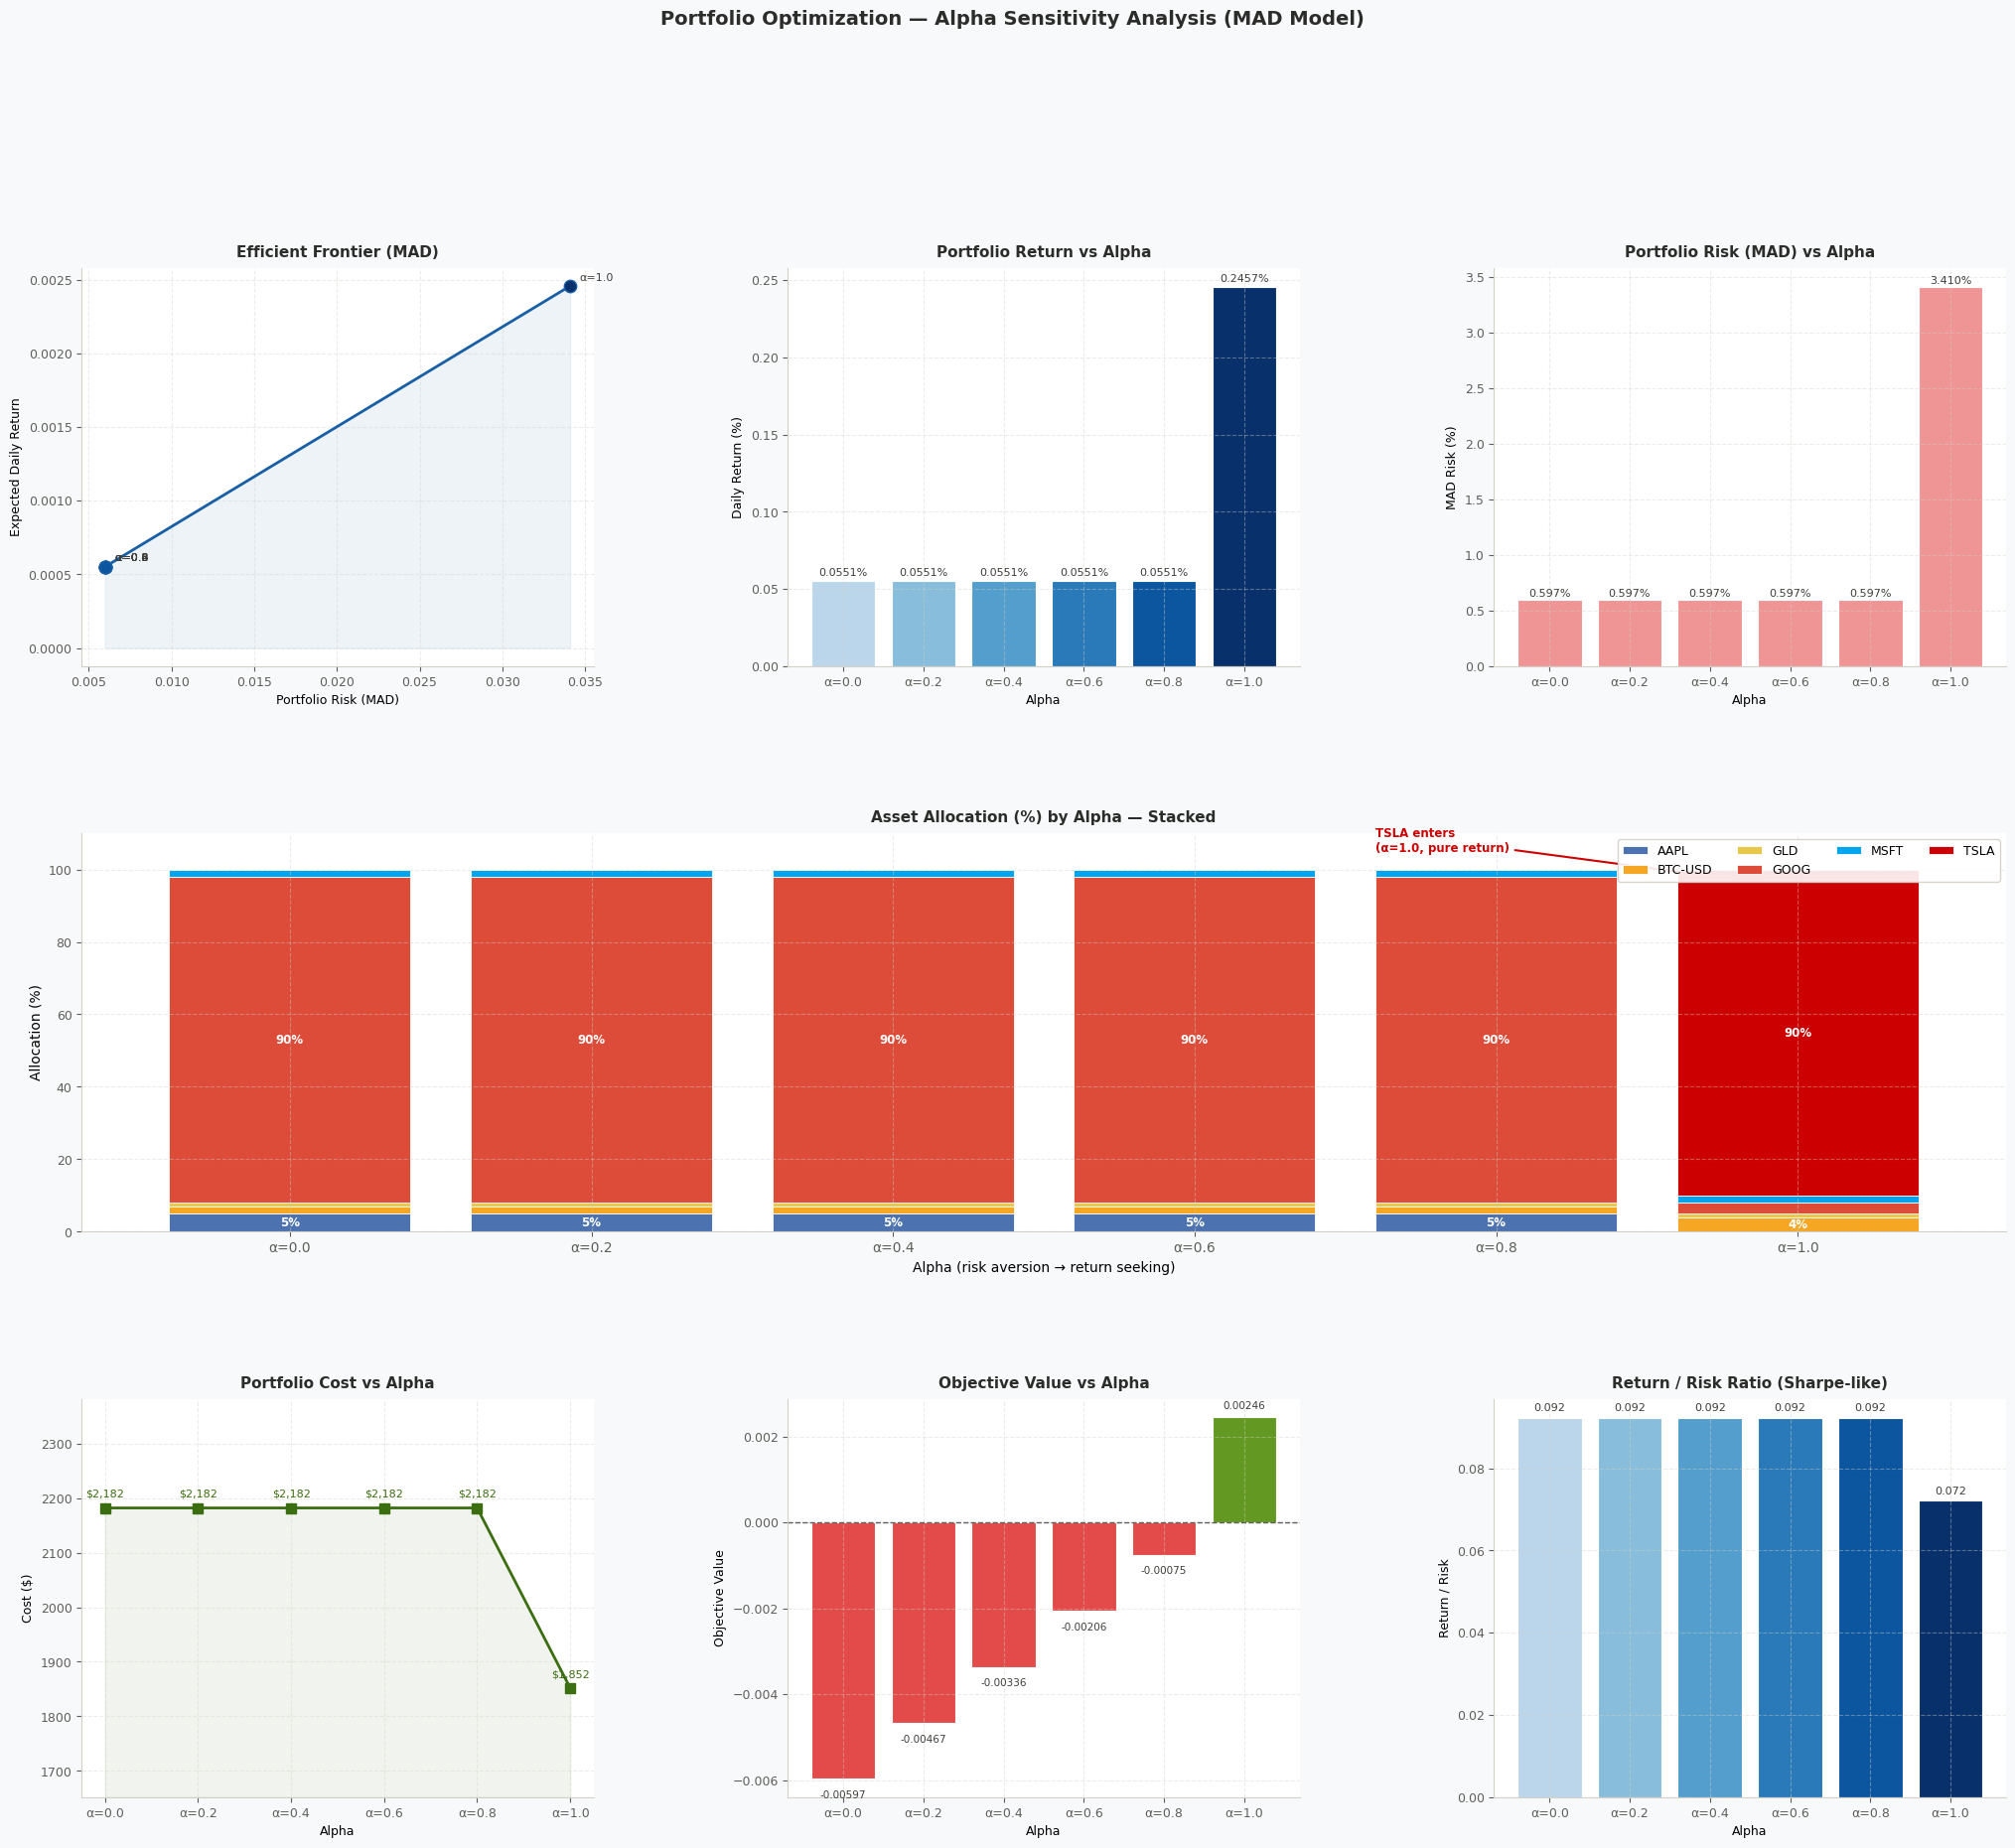

In [214]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import matplotlib.cm as cm



alphas   = sorted(results_alpha.keys())
assets   = ['AAPL', 'BTC-USD', 'GLD', 'GOOG', 'MSFT', 'RGTI', 'SAP', 'TSLA']
returns  = [results_alpha[a]['Portfolio Return']    for a in alphas]
risks    = [results_alpha[a]['Portfolio Risk (MAD)'] for a in alphas]
costs    = [results_alpha[a]['Portfolio Cost']       for a in alphas]
obj_vals = [results_alpha[a]['Objective Value']      for a in alphas]

# allocation matrix: rows=alpha, cols=assets
alloc_matrix = np.array([
    [results_alpha[a]['Allocations X'][asset] for asset in assets]
    for a in alphas
])

# ── Palette ───────────────────────────────────────────────────────────────────
ASSET_COLORS = {
    'AAPL':    '#4C72B0',
    'BTC-USD': '#F5A623',
    'GLD':     '#E8C84A',
    'GOOG':    '#DD4B39',
    'MSFT':    '#00A4EF',
    'RGTI':    '#7B68EE',
    'SAP':     '#21A366',
    'TSLA':    '#CC0000',
}
ALPHA_CMAP = cm.get_cmap('Blues', len(alphas) + 2)
ALPHA_COLORS = [ALPHA_CMAP(i + 2) for i in range(len(alphas))]


# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(25, 20))
fig.patch.set_facecolor('#F8F9FA')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.38)

ax1 = fig.add_subplot(gs[0, 0])      # efficient frontier
ax2 = fig.add_subplot(gs[0, 1])      # return vs alpha
ax3 = fig.add_subplot(gs[0, 2])      # risk vs alpha
ax4 = fig.add_subplot(gs[1, :])      # stacked bar allocation
ax5 = fig.add_subplot(gs[2, 0])      # portfolio cost vs alpha
ax6 = fig.add_subplot(gs[2, 1])      # objective value vs alpha
ax7 = fig.add_subplot(gs[2, 2])      # return/risk ratio vs alpha

def style(ax, title):
    ax.set_facecolor('#FFFFFF')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8, color='#2C2C2A')
    ax.tick_params(labelsize=9, colors='#5F5E5A')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#D3D1C7')
    ax.grid(True, linestyle='--', alpha=0.4, color='#D3D1C7')

alpha_labels = [f'α={a}' for a in alphas]



# ── 1. Efficient Frontier ─────────────────────────────────────────────────────
style(ax1, 'Efficient Frontier (MAD)')
ax1.plot(risks, returns, 'o-', color='#185FA5', lw=2, ms=7, zorder=3)
for i, (r, ret, a) in enumerate(zip(risks, returns, alphas)):
    ax1.scatter(r, ret, s=80, color=ALPHA_COLORS[i], zorder=4, edgecolors='#185FA5', lw=1)
    ax1.annotate(f'α={a}', (r, ret), textcoords='offset points',
                 xytext=(7, 4), fontsize=8, color='#3d3d3a')
ax1.set_xlabel('Portfolio Risk (MAD)', fontsize=9)
ax1.set_ylabel('Expected Daily Return', fontsize=9)
ax1.fill_between(risks, returns, alpha=0.07, color='#185FA5')

# ── 2. Return vs Alpha ────────────────────────────────────────────────────────
style(ax2, 'Portfolio Return vs Alpha')
bars = ax2.bar(alpha_labels, [r * 100 for r in returns], color=ALPHA_COLORS,
               edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, returns):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val*100:.4f}%', ha='center', va='bottom', fontsize=8, color='#3d3d3a')
ax2.set_ylabel('Daily Return (%)', fontsize=9)
ax2.set_xlabel('Alpha', fontsize=9)

# ── 3. Risk vs Alpha ──────────────────────────────────────────────────────────
style(ax3, 'Portfolio Risk (MAD) vs Alpha')
bars = ax3.bar(alpha_labels, [r * 100 for r in risks], color='#F09595',
               edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, risks):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val*100:.3f}%', ha='center', va='bottom', fontsize=8, color='#3d3d3a')
ax3.set_ylabel('MAD Risk (%)', fontsize=9)
ax3.set_xlabel('Alpha', fontsize=9)

# ── 4. Allocation per Alpha ────────────────────────────────────
style(ax4, 'Asset Allocation (%) by Alpha — Stacked')
x = np.arange(len(alphas))
bottoms = np.zeros(len(alphas))
for j, asset in enumerate(assets):
    vals = alloc_matrix[:, j] * 100
    if vals.sum() == 0:
        continue
    bars = ax4.bar(x, vals, bottom=bottoms, label=asset,
                   color=ASSET_COLORS[asset], edgecolor='white', linewidth=0.6)
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v > 3:
            ax4.text(bar.get_x() + bar.get_width()/2,
                     bottoms[i] + v/2,
                     f'{v:.0f}%', ha='center', va='center',
                     fontsize=8.5, fontweight='bold', color='white')
    bottoms += vals

ax4.set_xticks(x)
ax4.set_xticklabels(alpha_labels, fontsize=10)
ax4.set_ylabel('Allocation (%)', fontsize=10)
ax4.set_xlabel('Alpha (risk aversion → return seeking)', fontsize=10)
ax4.set_ylim(0, 110)
ax4.legend(loc='upper right', fontsize=9, ncol=4, framealpha=0.9,
           edgecolor='#D3D1C7')

# annotation: TSLA spike
ax4.annotate('TSLA enters\n(α=1.0, pure return)',
             xy=(5, 95), xytext=(3.6, 105),
             arrowprops=dict(arrowstyle='->', color='#CC0000', lw=1.5),
             fontsize=8.5, color='#CC0000', fontweight='bold')

# ── 5. Portfolio Cost vs Alpha ────────────────────────────────────────────────
style(ax5, 'Portfolio Cost vs Alpha')
ax5.plot(alpha_labels, costs, 's-', color='#3B6D11', lw=2, ms=7)
for i, (lbl, c) in enumerate(zip(alpha_labels, costs)):
    ax5.annotate(f'${c:,.0f}', (lbl, c), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=8, color='#3B6D11')
ax5.set_ylabel('Cost ($)', fontsize=9)
ax5.set_xlabel('Alpha', fontsize=9)
ax5.set_ylim(min(costs) - 200, max(costs) + 200)
ax5.fill_between(range(len(alphas)), costs, min(costs) - 200, alpha=0.07, color='#3B6D11')

# ── 6. Objective Value vs Alpha ───────────────────────────────────────────────
style(ax6, 'Objective Value vs Alpha')
colors_obj = ['#E24B4A' if v < 0 else '#639922' for v in obj_vals]
ax6.bar(alpha_labels, obj_vals, color=colors_obj, edgecolor='white', linewidth=0.8)
ax6.axhline(0, color='#5F5E5A', lw=1, linestyle='--')
for lbl, v in zip(alpha_labels, obj_vals):
    ax6.annotate(f'{v:.5f}', (lbl, v),
                 textcoords='offset points',
                 xytext=(0, 6 if v >= 0 else -14),
                 ha='center', fontsize=7.5, color='#3d3d3a')
ax6.set_ylabel('Objective Value', fontsize=9)
ax6.set_xlabel('Alpha', fontsize=9)

# ── 7. Return / Risk Ratio ────────────────────────────────────────────────────
style(ax7, 'Return / Risk Ratio (Sharpe-like)')
ratios = [ret / risk if risk > 0 else 0 for ret, risk in zip(returns, risks)]
ax7.bar(alpha_labels, ratios, color=ALPHA_COLORS, edgecolor='white', linewidth=0.8)
for lbl, v in zip(alpha_labels, ratios):
    ax7.annotate(f'{v:.3f}', (lbl, v),
                 textcoords='offset points', xytext=(0, 5),
                 ha='center', fontsize=8, color='#3d3d3a')
ax7.set_ylabel('Return / Risk', fontsize=9)
ax7.set_xlabel('Alpha', fontsize=9)

# ── Title ─────────────────────────────────────────────────────────────────────
fig.suptitle('Portfolio Optimization — Alpha Sensitivity Analysis (MAD Model)',
             fontsize=14, fontweight='bold', color='#2C2C2A', y=1.01)

